#### Notebook 1 : Linear regression single feature

##### Import libraries

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##### Load the data set

In [90]:
df = pd.read_csv('capstone.csv')

##### Check the shape of the data set

In [91]:
print(df.shape)

(150, 10)


##### Check the column names

In [92]:
print(df.columns)

Index(['MemberName', 'EducationLevel', 'Attendance', 'TotalHours',
       'AssignmentsCompleted', 'HackathonParticipation', 'GitHubScore',
       'PeerReviewScore', 'CourseName', 'CapstoneScore'],
      dtype='object')


##### Check the fisrt few instances of the data set

In [93]:
print(df.head(5))

                       MemberName  EducationLevel  Attendance  TotalHours  \
0           Theekshana Rathnayake               3        79.9        43.7   
1  Mayura Sandakalum Sellapperuma               2        76.8        95.6   
2                 Amila Narangoda               3        96.6        75.9   
3                    Nisal Gamage               1        74.5        63.9   
4                Tharusha Vihanga               2        83.2        24.0   

   AssignmentsCompleted  HackathonParticipation  GitHubScore  PeerReviewScore  \
0                     2                       0         62.8              5.0   
1                     6                       0         87.4              2.7   
2                     8                       0         98.4              2.8   
3                     7                       0         76.8              1.7   
4                     6                       0         41.8              4.2   

                    CourseName  CapstoneScore  
0 

##### Preprocess the Data

###### Prepare input (X) and target (y) vectors for training the linear regression model.

In [94]:
X = df['Attendance'].values
y = df['CapstoneScore'].values

# Quick check of shapes
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (150,)
y shape: (150,)


##### Implement the Cost Function

###### Calculate the mean squared error (MSE) between model’s predictions and actual values.

In [95]:
def compute_cost(X, y, beta_0, beta_1):
    m = len(y)  # number of data points
    predictions = beta_0 + beta_1 * X  # model predictions
    errors = predictions - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)  # MSE with 1/2m factor
    return cost


##### Testing it with dummy values

In [96]:

test_cost = compute_cost(X, y, beta_0=0, beta_1=0)
print(f"Initial cost (beta_0=0, beta_1=0): {test_cost:.2f}")


Initial cost (beta_0=0, beta_1=0): 2235.57


#####  Implement compute gradients

###### Compute the gradients (slopes) of the cost function with respect to beta_0 and beta_1 to know how to adjust beta_0 and beta_1 to reduce the cost

In [97]:
def compute_gradients(X, y, beta_0, beta_1):
    m = len(y)
    predictions = beta_0 + beta_1 * X
    errors = predictions - y
    db0 = (1 / m) * np.sum(errors)
    db1 = (1 / m) * np.sum(errors * X)
    return db0, db1


##### Testing with Dummy values

In [98]:
db0, db1 = compute_gradients(X, y, beta_0=0, beta_1=0)
print(f"Gradient for beta_0: {db0:.2f}")
print(f"Gradient for beta_1: {db1:.2f}")


Gradient for beta_0: -62.14
Gradient for beta_1: -4859.33


##### Implement gradient descent

###### Iteratively update beta_0 and beta_1 to minimize the cost using the gradients



In [99]:
def gradient_descent(X, y, learning_rate=0.01, num_iterations=1000):
    beta_0 = 0
    beta_1 = 0
    cost_history = []

    for i in range(num_iterations):
        # Compute gradients
        db0, db1 = compute_gradients(X, y, beta_0, beta_1)

        # Update parameters
        beta_0 -= learning_rate * db0
        beta_1 -= learning_rate * db1

        # Compute and store the cost
        cost = compute_cost(X, y, beta_0, beta_1)
        cost_history.append(cost)

        # Print every 100 steps
        if i % 100 == 0 or i == num_iterations - 1:
            print(f"Iteration {i}: Cost={cost:.2f}, beta_0={beta_0:.2f}, beta_1={beta_1:.2f}")

    return beta_0, beta_1, cost_history


##### Run the training with a learning rate

* Testing with alpha = 0.00001 (without scaling)

In [100]:
beta_0, beta_1, cost_history = gradient_descent(X, y, learning_rate=0.00001, num_iterations=1000)
print(f"Final beta_0: {beta_0:.4f}")
print(f"Final beta_1: {beta_1:.4f}")

Iteration 0: Cost=2006.71, beta_0=0.00, beta_1=0.05
Iteration 100: Cost=327.39, beta_0=0.01, beta_1=0.78
Iteration 200: Cost=327.39, beta_0=0.01, beta_1=0.79
Iteration 300: Cost=327.38, beta_0=0.01, beta_1=0.79
Iteration 400: Cost=327.38, beta_0=0.01, beta_1=0.79
Iteration 500: Cost=327.38, beta_0=0.01, beta_1=0.79
Iteration 600: Cost=327.38, beta_0=0.02, beta_1=0.79
Iteration 700: Cost=327.38, beta_0=0.02, beta_1=0.79
Iteration 800: Cost=327.38, beta_0=0.02, beta_1=0.79
Iteration 900: Cost=327.38, beta_0=0.02, beta_1=0.79
Iteration 999: Cost=327.38, beta_0=0.02, beta_1=0.79
Final beta_0: 0.0200
Final beta_1: 0.7851


#####  Plot the Cost Over Iterations

* Visualizing how the cost decreased with each iteration, to analyze convergence behavior

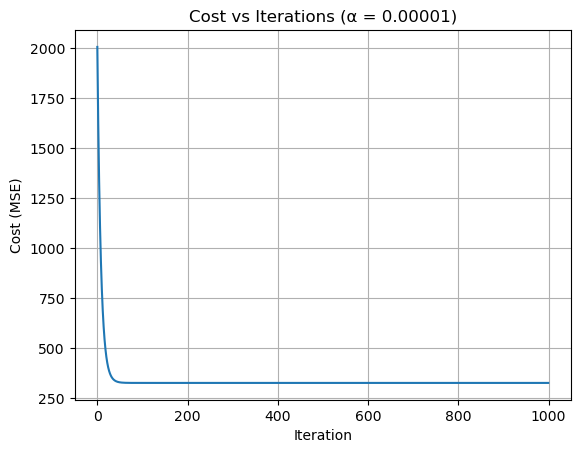

In [101]:
plt.plot(range(len(cost_history)), cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Cost vs Iterations (α = 0.00001)')
plt.grid(True)
plt.show()


* Testing with alpha = 0.001 (without scaling)

Iteration 0: Cost=51693.21, beta_0=0.06, beta_1=4.86
Iteration 100: Cost=5200354867560658675000343052759493788704133738488902484179210525444670865510682802101526164422654154347429502583018685694474209597677836229465341952.00, beta_0=16307267244513363745963887987120606175121087553336177355547576950063104.00, beta_1=1296315546281379966247970128673384704697456688456326529048213959926087680.00
Iteration 200: Cost=526491907930839359866870421539949985748801476737704443049265973059903062404501407349374831538966069981639243465500114801073621021289196569694397242387380793090915332069680534144764182766183057613578877209121187793795093500265813557529318775963261387312918717060386640782988188879633386569728.00, beta_0=5188723741054799531567019441103988014424383084760831370563251168258855562909442893093987631847128758892762330358451364110769711623756968886272.00, beta_1=4124678371939773400543599107116850474455040365646098097822263296430671666532010840535617670498312814621432987300007493817654908662

c:\Users\HP\anaconda3\envs\ml-env\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\HP\AppData\Local\Temp\ipykernel_2844\2999658015.py:5: RuntimeWarning: overflow encountered in square
  cost = (1 / (2 * m)) * np.sum(errors ** 2)  # MSE with 1/2m factor
C:\Users\HP\AppData\Local\Temp\ipykernel_2844\2736247790.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  beta_1 -= learning_rate * db1


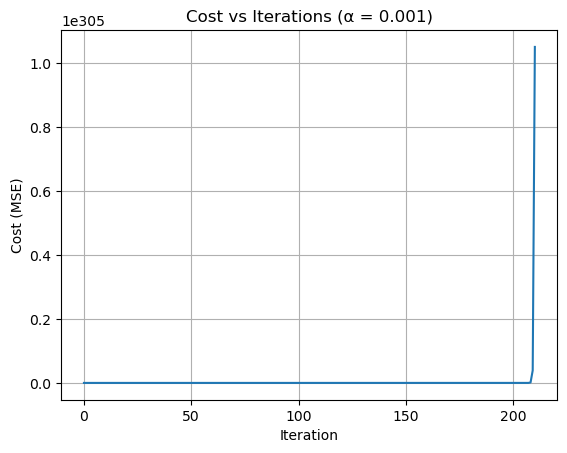

In [102]:
beta_0, beta_1, cost_history = gradient_descent(X, y, learning_rate=0.001, num_iterations=1000)
print(f"Final beta_0: {beta_0:.4f}")
print(f"Final beta_1: {beta_1:.4f}")

plt.plot(range(len(cost_history)), cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Cost vs Iterations (α = 0.001)')
plt.grid(True)
plt.show()


* Gradient Explosion happened due to Large Feature Scale + Too High Learning Rate. 
* To prevent this, should normalize the input feature (standardization) and rerun gradient descent using the scaled data.


In [103]:
# Feature scaling (standardization)
X_mean = np.mean(X)
X_std = np.std(X)
X_scaled = (X - X_mean) / X_std


* Testing again with alpha = 0.001 (after scaling)

In [104]:
beta_0, beta_1, cost_history = gradient_descent(X_scaled, y, learning_rate=0.001, num_iterations=1000)
print(f"Final beta_0: {beta_0:.4f}")
print(f"Final beta_1: {beta_1:.4f}")


Iteration 0: Cost=2231.71, beta_0=0.06, beta_1=0.00
Iteration 100: Cost=1881.94, beta_0=5.97, beta_1=0.19
Iteration 200: Cost=1595.60, beta_0=11.32, beta_1=0.37
Iteration 300: Cost=1361.19, beta_0=16.16, beta_1=0.52
Iteration 400: Cost=1169.29, beta_0=20.54, beta_1=0.67
Iteration 500: Cost=1012.19, beta_0=24.50, beta_1=0.79
Iteration 600: Cost=883.58, beta_0=28.08, beta_1=0.91
Iteration 700: Cost=778.30, beta_0=31.32, beta_1=1.02
Iteration 800: Cost=692.10, beta_0=34.26, beta_1=1.11
Iteration 900: Cost=621.54, beta_0=36.91, beta_1=1.20
Iteration 999: Cost=564.30, beta_0=39.29, beta_1=1.27
Final beta_0: 39.2897
Final beta_1: 1.2738


* Visualizing how the cost decreased with each iteration, to analyze convergence behavior

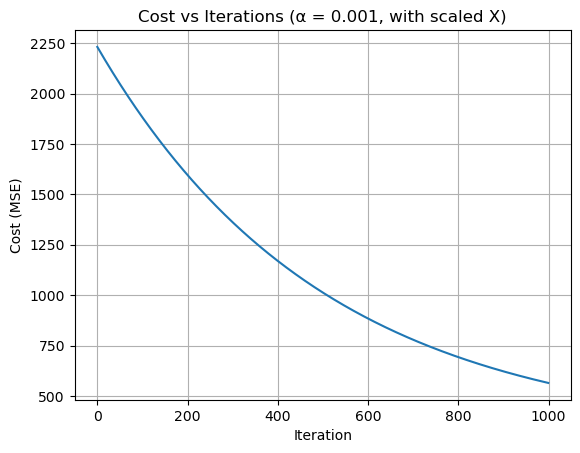

In [105]:
plt.plot(range(len(cost_history)), cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Cost vs Iterations (α = 0.001, with scaled X)')
plt.grid(True)
plt.show()


* Testing with alpha = 0.1 using scaled data

In [106]:
beta_0, beta_1, cost_history = gradient_descent(X_scaled, y, learning_rate=0.1, num_iterations=1000)
print(f"Final beta_0: {beta_0:.4f}")
print(f"Final beta_1: {beta_1:.4f}")


Iteration 0: Cost=1868.39, beta_0=6.21, beta_1=0.20
Iteration 100: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 200: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 300: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 400: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 500: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 600: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 700: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 800: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 900: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 999: Cost=303.02, beta_0=62.14, beta_1=2.01
Final beta_0: 62.1373
Final beta_1: 2.0145


* Visualizing how the cost decreased with each iteration, to analyze convergence behavior

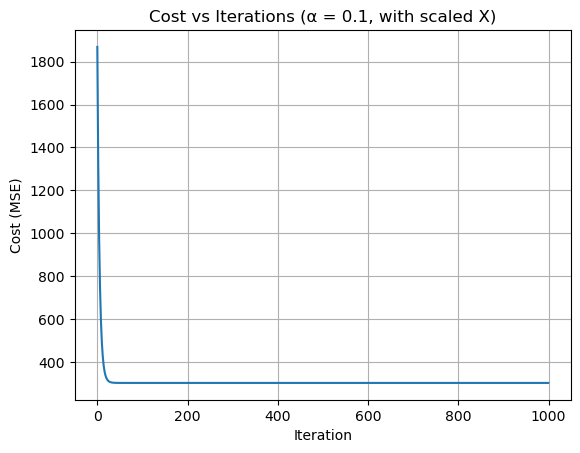

In [107]:
plt.plot(range(len(cost_history)), cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Cost vs Iterations (α = 0.1, with scaled X)')
plt.grid(True)
plt.show()


* Testing with alpha = 1.0 using scaled data

In [108]:
beta_0, beta_1, cost_history = gradient_descent(X_scaled, y, learning_rate=1.0, num_iterations=1000)
print(f"Final beta_0: {beta_0:.4f}")
print(f"Final beta_1: {beta_1:.4f}")

Iteration 0: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 100: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 200: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 300: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 400: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 500: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 600: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 700: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 800: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 900: Cost=303.02, beta_0=62.14, beta_1=2.01
Iteration 999: Cost=303.02, beta_0=62.14, beta_1=2.01
Final beta_0: 62.1373
Final beta_1: 2.0145


* Visualizing how the cost decreased with each iteration, to analyze convergence behavior

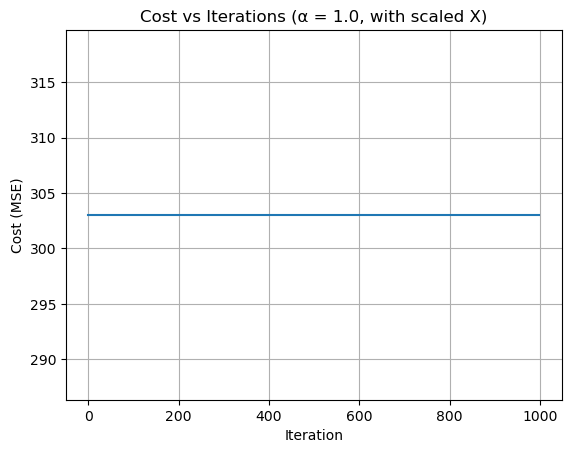

In [109]:
plt.plot(range(len(cost_history)), cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Cost vs Iterations (α = 1.0, with scaled X)')
plt.grid(True)
plt.show()


* Testing with alpha = 0.00001 using scaled data (just to see the values for easy comparison)

In [110]:
beta_0, beta_1, cost_history = gradient_descent(X_scaled, y, learning_rate=0.00001, num_iterations=1000)
print(f"Final beta_0: {beta_0:.4f}")
print(f"Final beta_1: {beta_1:.4f}")


Iteration 0: Cost=2235.53, beta_0=0.00, beta_1=0.00
Iteration 100: Cost=2231.67, beta_0=0.06, beta_1=0.00
Iteration 200: Cost=2227.82, beta_0=0.12, beta_1=0.00
Iteration 300: Cost=2223.97, beta_0=0.19, beta_1=0.01
Iteration 400: Cost=2220.14, beta_0=0.25, beta_1=0.01
Iteration 500: Cost=2216.31, beta_0=0.31, beta_1=0.01
Iteration 600: Cost=2212.48, beta_0=0.37, beta_1=0.01
Iteration 700: Cost=2208.67, beta_0=0.43, beta_1=0.01
Iteration 800: Cost=2204.86, beta_0=0.50, beta_1=0.02
Iteration 900: Cost=2201.06, beta_0=0.56, beta_1=0.02
Iteration 999: Cost=2197.31, beta_0=0.62, beta_1=0.02
Final beta_0: 0.6183
Final beta_1: 0.0200


* Visualizing how the cost decreased with each iteration, to analyze convergence behavior

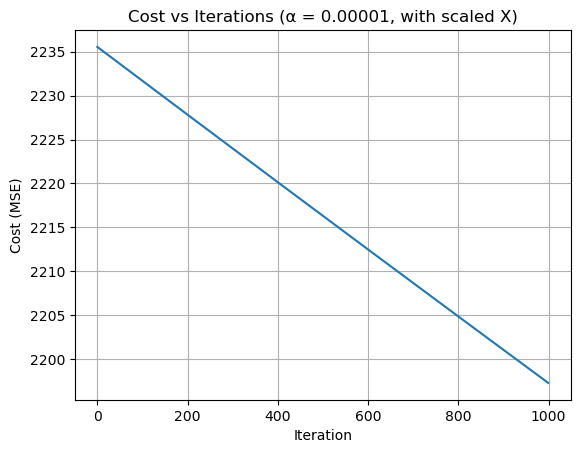

In [111]:
plt.plot(range(len(cost_history)), cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Cost vs Iterations (α = 0.00001, with scaled X)')
plt.grid(True)
plt.show()


##### Implement and Test the predict() Function

* Generating predictions using the final beta_0, beta_1

In [112]:
def predict(X, beta_0, beta_1):
    return beta_0 + beta_1 * X


* Making predictions using the scaled X

In [113]:
y_pred = predict(X_scaled, beta_0, beta_1)

##### Plot data and regression line

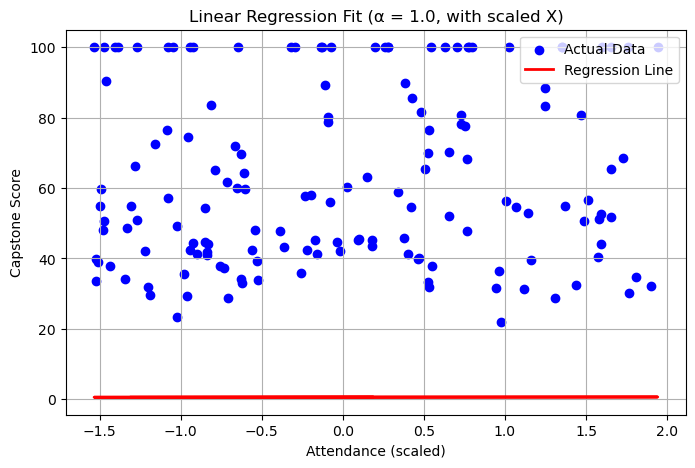

In [114]:
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled, y, color='blue', label='Actual Data')
plt.plot(X_scaled, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Attendance (scaled)')
plt.ylabel('Capstone Score')
plt.title('Linear Regression Fit (α = 1.0, with scaled X)')
plt.legend()
plt.grid(True)
plt.show()
